## Find protein sequences

In [17]:
# --- НАСТРОЙКИ ---
results_dir = "../data/annotations"
input_file = "./data/annotations/GCA_902796445.1_annot/GCA_902796445.1.faa"
target_id = "BBJOLO_00049"
genome_id = "GCA_902796445.1"
window_size = 7  # сколько белков взять до и после

In [43]:
# --- НАСТРОЙКИ ---
results_dir = "../data/annotations"
input_file = "/data/annotations/GCA_902777215.1_annot/GCA_902777215.1.faa"
target_id = "FFNCOF_00675"
genome_id = "GCA_902777215.1"
window_size = 7  # сколько белков взять до и после

In [11]:
import os
from Bio import SeqIO

# 1. Загружаем записи из файла
records = list(SeqIO.parse(input_file, "fasta"))

# 2. Ищем индекс нужного белка
target_idx = None
for i, record in enumerate(records):
    if target_id in record.id:
        target_idx = i
        break

if target_idx is None:
    print(f"{target_id} is not found")
else:
    # 3. Определяем границы среза
    start = max(0, target_idx - window_size)
    end = target_idx + window_size + 1
    neighborhood = records[start:end]

    # 4. Создаем папку для результата
    folder_name = f"{results_dir}/results_{genome_id}_{target_id}"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    # 5. Сохраняем результат в новую папку
    output_filename = f"{genome_id}_{target_id}.faa"
    output_path = os.path.join(folder_name, output_filename)
    
    SeqIO.write(neighborhood, output_path, "fasta")

    print(f"Save in: {output_path}")
    print(f"Total: {len(neighborhood)}")


Save in: results_GCA_902777215.1_FFNCOF_00675/GCA_902777215.1_FFNCOF_00675.faa
Total: 15


## Blast NCBI

In [12]:
import time
import socket
from Bio import SeqIO
from Bio.Blast import NCBIWWW, NCBIXML

socket.setdefaulttimeout(180) 

INPUT_FASTA = f"{results_dir}/results_{genome_id}_{target_id}/{genome_id}_{target_id}.faa"

def get_best_blast_hit(sequence, seq_id, max_retries=3):
    if not sequence.strip("X* \n\t"):
        return "Sequence consists of gaps (Ns) only"
    
    for attempt in range(max_retries):
        print(f"Searching BLAST for {seq_id} (Attempt {attempt + 1})... ", end="", flush=True)
        try:
            # Увеличиваем таймаут, чтобы не обрывалось при долгой обработке
            result_handle = NCBIWWW.qblast("blastp", "nr", sequence)
            blast_record = NCBIXML.read(result_handle)
            
            if blast_record.alignments:
                # Обрезаем лишние совпадения по символу '>'
                best_hit = blast_record.alignments[0].title.split('>')[0].strip()
                print("Done.")
                return best_hit
            else:
                print("No hits.")
                return "No hits found"
                
        except Exception as e:
            print(f"Error: {e}")
            if attempt < max_retries - 1:
                wait_time = 30
                print(f"Retrying in {wait_time} seconds...")
                time.sleep(wait_time)
            else:
                return f"BLAST error after {max_retries} attempts: {str(e)}"

# Основной цикл
print()
with open(f"{results_dir}/results_{genome_id}_{target_id}/blast_results.txt", "w") as out_f:
    for record in SeqIO.parse(INPUT_FASTA, "fasta"):
        description = get_best_blast_hit(str(record.seq), record.id)
        
        # Формируем строку результата
        result_line = f"ID: {record.id}\nDESC: {description}\n" + "-"*30
        
        # Выводим в терминал и записываем в файл
        print(result_line)
        out_f.write(result_line + "\n")
        
        # Пауза между запросами (важно для NCBI)
        time.sleep(10)

print("\nAll results save in blast_results.txt")



Searching BLAST for FFNCOF_00668 (Attempt 1)... Done.
ID: FFNCOF_00668
DESC: gb|MBR0542801.1| MBL fold metallo-hydrolase [Clostridia bacterium]
------------------------------
Searching BLAST for FFNCOF_00669 (Attempt 1)... Done.
ID: FFNCOF_00669
DESC: tpg|HAQ64154.1| hypothetical protein [Oscillospiraceae bacterium]
------------------------------
Searching BLAST for FFNCOF_00670 (Attempt 1)... Done.
ID: FFNCOF_00670
DESC: tpg|HAQ64155.1| hypothetical protein [Oscillospiraceae bacterium]
------------------------------
Searching BLAST for FFNCOF_00671 (Attempt 1)... Done.
ID: FFNCOF_00671
DESC: gb|MBR0542798.1| hypothetical protein [Clostridia bacterium]
------------------------------
Searching BLAST for FFNCOF_00672 (Attempt 1)... Done.
ID: FFNCOF_00672
DESC: gb|MBR0542797.1| alpha-glucosidase [Clostridia bacterium]
------------------------------
Searching BLAST for FFNCOF_00673 (Attempt 1)... Done.
ID: FFNCOF_00673
DESC: gb|MDO4846513.1| glycoside-pentoside-hexuronide (GPH):cation sym

## Merge annotations

In [13]:
import re

target_protein = target_id
gff_input = f"{results_dir}/{genome_id}_annot/{genome_id}.gff3"
desc_file = f"{results_dir}/results_{genome_id}_{target_id}/blast_results.txt"
output_gff =  f"{results_dir}/results_{genome_id}_{target_id}/extracted_neighborhood.gff"

# --- ЭТАП 1: Парсим файл с описаниями в словарь ---
descriptions = {}
with open(desc_file, 'r') as f:
    blocks = f.read().split('------------------------------')
    for block in blocks:
        id_match = re.search(r'ID:\s+(\S+)', block)
        # Ищем текст после DESC. 
        # (?:.*?\|)? - находит и отбрасывает всё до '|' включительно
        product_match = re.search(r'DESC:\s+(?:.*?\|)?\s*(.*?)(?:\s\[|$)', block)
        
        if id_match and product_match:
            protein_id = id_match.group(1)
            raw_desc = product_match.group(1).strip()
            
            # 1. Базовая очистка от префиксов (gb|..., MAG:, и т.д.)
            clean_name = raw_desc.split('|')[-1].strip()
            clean_name = re.sub(r'^[A-Z]{2,}:|^\w+=', '', clean_name).strip()
            
            # 2. Унификация гипотетических белков
            if "hypothetical protein" in clean_name.lower():
                clean_name = "hypothetical protein"
            
            descriptions[protein_id] = clean_name

# --- ЭТАП 2: Поиск целевой строки и выборка соседей ---
with open(gff_input, 'r') as f:
    lines = [line for line in f if not line.startswith('#')]

target_idx = None
for i, line in enumerate(lines):
    if target_protein in line:
        target_idx = i
        break

if target_idx is None:
    print(f"Protein {target_protein} not found!")
    exit()

# Берем срез
start_idx = max(0, target_idx - window_size)
end_idx = min(len(lines), target_idx + window_size + 1)
neighborhood = lines[start_idx:end_idx]

# --- ЭТАП 3: Добавление описаний и сохранение ---
with open(output_gff, 'w') as out:
    out.write("##gff-version 3\n")
    
    for line in neighborhood:
        cols = line.strip().split('\t')
        if len(cols) < 9:
            out.write(line)
            continue
        
        attributes = cols[8]
        
        # 1. Пытаемся найти ID в атрибутах GFF (ищем занчение после ID=)
        id_match = re.search(r'(?:ID|Name|locus_tag)=([^;]+)', attributes)
        
        if id_match:
            gff_id = id_match.group(1)
            
            # 2. Проверяем, есть ли этот ID в нашем словаре
            if gff_id in descriptions:
                product_info = descriptions[gff_id]
                # Добавляем новую аннотацию в конец 9-й колонки
                cols[8] = f"{attributes};blast_product={product_info}"
        
        # Собираем строку обратно
        out.write('\t'.join(cols) + '\n')

print(f"Done! Results save in: {output_gff}")


Done! Results save in: results_GCA_902777215.1_FFNCOF_00675/extracted_neighborhood.gff


## Plot neighborhood

In [39]:
import matplotlib.pyplot as plt
from BCBio import GFF
from dna_features_viewer import BiopythonTranslator
import hashlib
import textwrap

output_png = f"{results_dir}/results_{genome_id}_{target_id}/landscape_{genome_id}_{target_id}.png"

class MyCustomTranslator(BiopythonTranslator):
    def compute_feature_label(self, feature):
        product_val = feature.qualifiers.get("product", [""])
        product = ", ".join([str(v) for v in product_val]) if product_val else ""
        
        # Если product = hypothetical protein
        if "hypothetical protein" in product.lower():
            blast_val = feature.qualifiers.get("blast_product", [""])
            blast = ", ".join([str(v) for v in blast_val]) if blast_val else ""
            
            # Если blast_product существует и не "No hits found", берём его
            if blast and "no hits found" not in blast.lower():
                label = blast
            else:
                label = product
        else:
            label = product
        
        return "\n".join(textwrap.wrap(label, width=20)) if label else "Unknown"

    def compute_feature_color(self, feature):
        label = self.compute_feature_label(feature)
        
        hash_hex = hashlib.md5(label.encode()).hexdigest()
        return "#" + hash_hex[:6]

def visualize_neighborhood(gff_path, line_start=0, line_end=None):
    with open(gff_path) as in_handle:
        for record in GFF.parse(in_handle):
            if not record.features:
                continue

            all_features = [
                f for f in record.features 
                if "gap" not in str(f.qualifiers.get("product", [""])).lower() 
                and f.type.lower() != "gap"
            ]

            selected_features = all_features[line_start:line_end]
            if not selected_features:
                return

            start_coord = int(selected_features[0].location.start)
            end_coord = int(selected_features[-1].location.end)

            # Оставляем только выбранные фичи, не обрезая саму запись record
            record.features = selected_features
            
            translator = MyCustomTranslator()
            graphic_record = translator.translate_record(record)

            ax, _ = graphic_record.plot(
                figure_width=18,
                figure_height=6, 
                strand_in_label_threshold=1
            )

            # Рассчитываем отступ: чем длиннее название последнего гена, тем больше запас
            # Берем 30% от длины региона в качестве буфера справа
            x_range = end_coord - start_coord
            ax.set_xlim(start_coord - 200, end_coord + (x_range * 0.3))

            # Сдвигаем всё влево, чтобы справа было пустое место
            plt.subplots_adjust(right=0.75, left=0.1)

            ax.set_title(f"SQ locus in {genome_id}", loc='center', fontsize=14)
            
            plt.savefig(output_png, dpi=300, bbox_inches='tight')
            print(f"Save picture in: {output_png}")
            
            plt.show()
            plt.close()
            return


Save picture in: ../data/annotations/results_GCA_902796445.1_BBJOLO_00049/landscape_GCA_902796445.1_BBJOLO_00049.png


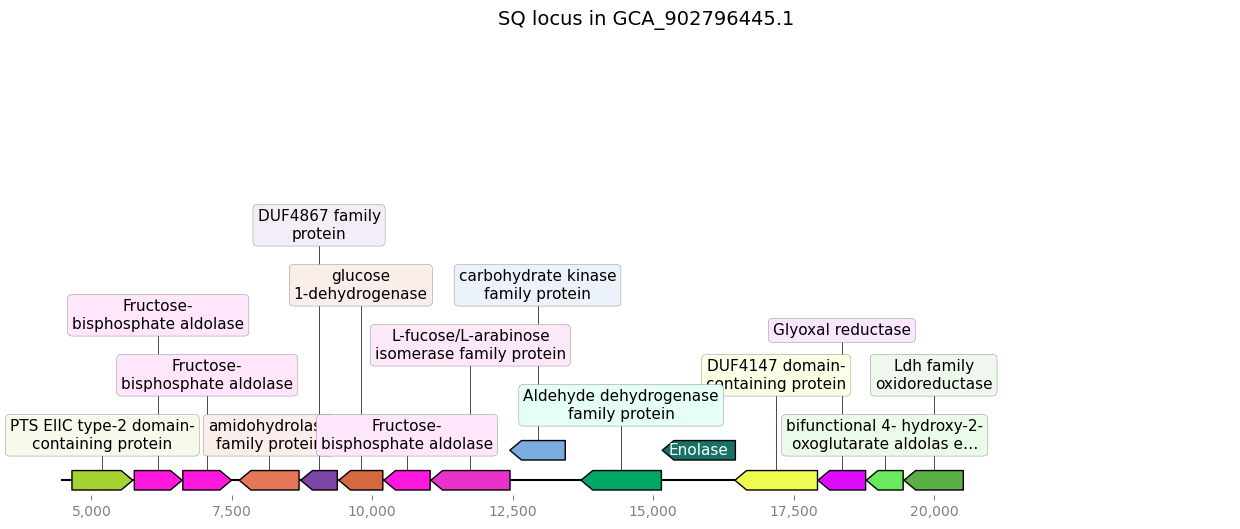

In [41]:
visualize_neighborhood(f"{results_dir}/results_{genome_id}_{target_id}/extracted_neighborhood.gff", line_start=0, line_end=15)

Save picture in: ../data/annotations/results_GCA_902796445.1_BBJOLO_00049/landscape_GCA_902796445.1_BBJOLO_00049.png


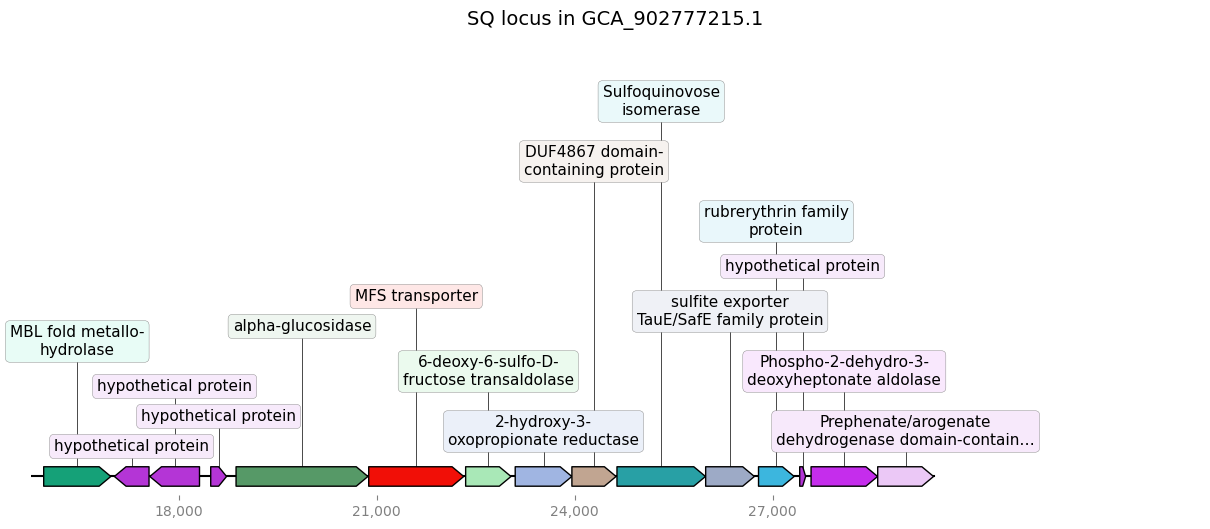

In [44]:
visualize_neighborhood(f"{results_dir}/results_{genome_id}_{target_id}/extracted_neighborhood.gff")